In [1]:
from OSCC_postprocessing.binary_ops.functions_bw import *
from OSCC_postprocessing.playback.video_playback import *
import numpy as np
from pathlib import Path
import sys
sys.path.append(r"C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py")  # Adjust this path to where mie_single_hole is located
from mie_single_hole import *
import matplotlib.pyplot as plt

def _as_numpy(arr):
    if USING_CUPY and hasattr(arr, "__cuda_array_interface__"):
        return cp.asnumpy(arr)
    return np.asarray(arr)


In [112]:
file = r"G:\MeOH_test\Mie\Processed_Results\Postprocessed_Data\T1_Mie Camera_3_boundary_points.csv"

# Threshold
thres_penetration_num_pix=5

# Original video shape
F=200
H=768//3
W=768

# list of frames for debugging
list_frames = np.linspace(0, F, 25, endpoint=False).astype(np.uint8)

# Default line of sight orthorgonal to plume
umbrella_angle = 180

nozzle_opening_detection_height = 40
nozzle_opening_detection_width = 10

In [113]:
# load boundary 
bw_video, boundary = load_boundary_file(file, return_BW_video=True, F=F, H=H, W=W)
bw_video = np.asarray(bw_video)

In [114]:
# play_video_cv2(bw_video*255.0)

In [115]:
bw_video_col_sum = np.sum(bw_video, axis=1) # type:ignore
area = bw_video_col_sum.sum(axis=-1)

# 
penetration_bw_x = penetration_bw_to_index(bw_video_col_sum > thres_penetration_num_pix)


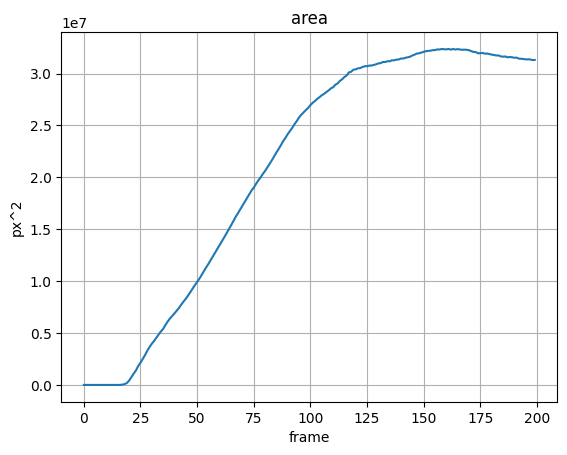

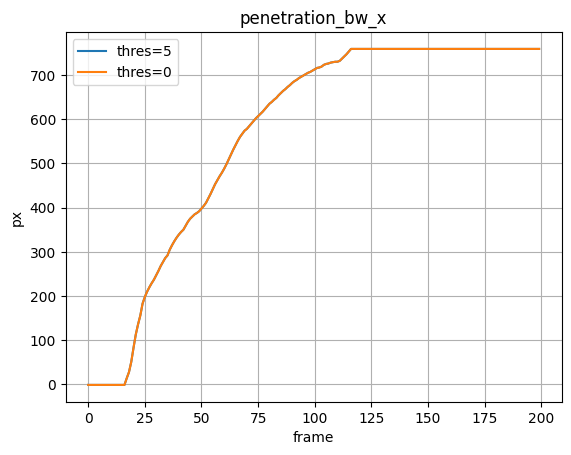

In [116]:
# plot area
plt.plot(area)
plt.title("area")
plt.xlabel("frame")
plt.ylabel("px^2")
plt.grid()
plt.show()

# plot penetration 
plt.plot(penetration_bw_x, label=f"thres={thres_penetration_num_pix}")
plt.plot(penetration_bw_to_index(bw_video_col_sum > 0), label="thres=0")
plt.title("penetration_bw_x")
plt.xlabel("frame")
plt.ylabel("px")
plt.legend()
plt.grid()
plt.show()

In [117]:

boundary_debug = bw_boundaries_all_points_single_plume(bw_video, parallel=True, umbrella_angle=180.0)


(0.0, 768.0)

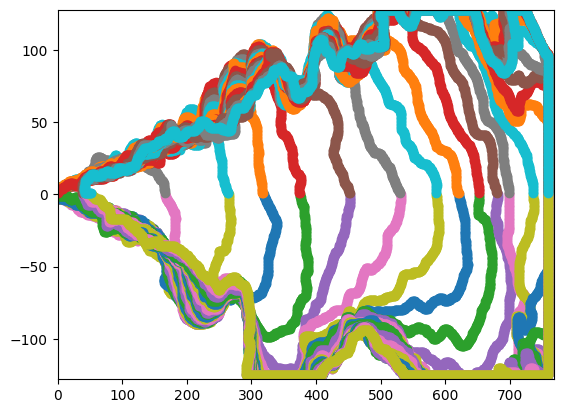

In [118]:

for i in list_frames:
    plt.scatter(boundary_debug[int(i)][0][:,1], boundary_debug[int(i)][0][:,0])
    plt.scatter(boundary_debug[int(i)][1][:,1], boundary_debug[int(i)][1][:,0])
    # print(boundary_debug[int(i)][0])
plt.ylim(-H//2, H//2)

plt.xlim(0, W)

In [119]:
upper_bw_width = bw_video[:, : H // 2, :].sum(axis=1)
lower_bw_width = bw_video[:, H // 2 :, :].sum(axis=1)


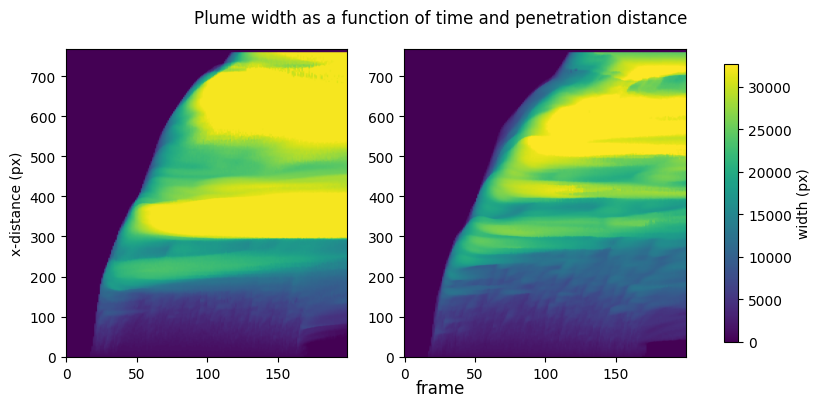

In [120]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))


vmin = min(np.nanmin(upper_bw_width), np.nanmin(lower_bw_width))
vmax = max(np.nanmax(upper_bw_width), np.nanmax(lower_bw_width))

im0 = ax[0].imshow(
    upper_bw_width.T,
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)

im1 = ax[1].imshow(
    lower_bw_width.T,
    origin="lower",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)

fig.suptitle("Plume width as a function of time and penetration distance")
ax[0].set_ylabel("x-distance (px)")
fig.supxlabel("frame")

cbar = fig.colorbar(im0, ax=ax, shrink=0.9)
cbar.set_label("width (px)")

plt.show()



In [121]:

if umbrella_angle == 180.0:
    x_scale = 1.0
else:
    tilt_angle = (180.0 - umbrella_angle) / 2.0
    tilt_angle_rad = tilt_angle / 180.0 * np.pi
    x_scale = 1.0 / np.cos(tilt_angle_rad)


In [122]:
estimated_volume = x_scale * np.pi * 0.25 * np.sum((upper_bw_width + lower_bw_width) ** 2, axis=1)

max_plume_radius = np.maximum(upper_bw_width, lower_bw_width)
min_plume_radius = np.minimum(upper_bw_width, lower_bw_width)

estimated_volume_max = np.pi * x_scale * np.sum(max_plume_radius**2, axis=1)
estimated_volume_min = np.pi * x_scale * np.sum(min_plume_radius**2, axis=1)

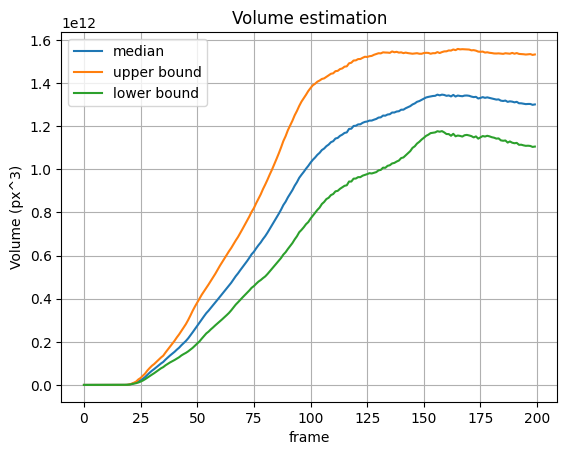

In [123]:
plt.plot(estimated_volume, label="median")
plt.plot(estimated_volume_max, label="upper bound")
plt.plot(estimated_volume_min, label="lower bound")
plt.title("Volume estimation")
plt.ylabel("Volume (px^3)")
plt.xlabel("frame")
plt.legend()
plt.grid()

In [124]:
# Polar penetration 
penetration_bw_polar = np.zeros(F)
for i in range(F):
    pts = boundary_debug[i]

    if pts is None or len(pts) < 2:
        boundary_debug[i] = []
        continue

    if len(pts[0]) > 0 and len(pts[1]) > 0:
        uy, ux = pts[1][:, 0], pts[1][:, 1]
        ly, lx = pts[0][:, 0], pts[0][:, 1]

        max_r_upper = np.max(np.sqrt(uy**2 + ux**2))
        max_r_lower = np.max(np.sqrt(ly**2 + lx**2))
        penetration_bw_polar[i] = max(max_r_upper, max_r_lower)

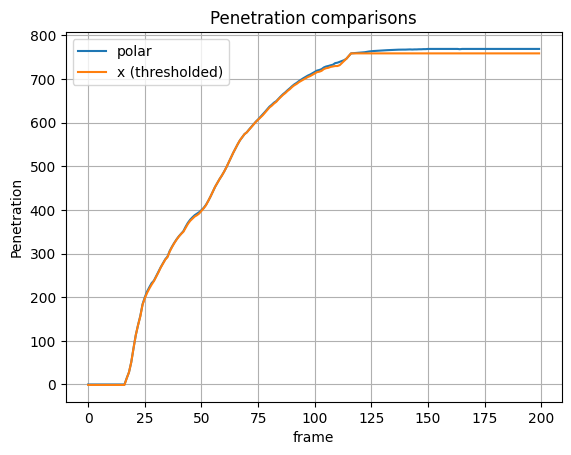

In [125]:
plt.plot(penetration_bw_polar, label="polar")
plt.plot(penetration_bw_x, label="x (thresholded)")
plt.legend()
plt.title("Penetration comparisons")
plt.ylabel("Penetration")
plt.xlabel("frame")
plt.grid()

In [126]:
# boudary points 10-60% penetration 
points_all_frames = bw_boundaries_xband_filter_single_plume(boundary_debug, _as_numpy(penetration_bw_x))


In [ ]:
# Cone angle 
# lg: linear regression
# avg: pixel wise average
lg_up = np.full(F, np.nan)
lg_low = np.full(F, np.nan)
avg_up = np.full(F, np.nan)
avg_low = np.full(F, np.nan)

for i in range(F):
    points = points_all_frames[i]
    if (len(points[0]) > 0) and (len(points[1]) > 0) and (penetration_bw_polar[i] > 0):
        uy, ux = points[1][:, 0], points[1][:, 1]
        ly, lx = points[0][:, 0], points[0][:, 1]

        ang_up = np.atan(uy / ux) * 180.0 / np.pi
        ang_low = np.atan(ly / lx) * 180.0 / np.pi

        avg_up[i] = np.nanmean(ang_up)
        avg_low[i] = np.nanmean(ang_low)

        try:
            lg_up[i] = np.atan(linear_regression_fixed_intercept(ux, uy, 0.0)) * 180.0 / np.pi
            lg_low[i] = np.atan(linear_regression_fixed_intercept(lx, ly, 0.0)) * 180.0 / np.pi
        except ValueError:
            pass

cone_angle_average = avg_up - avg_low
cone_angle_linear_regression = lg_up - lg_low

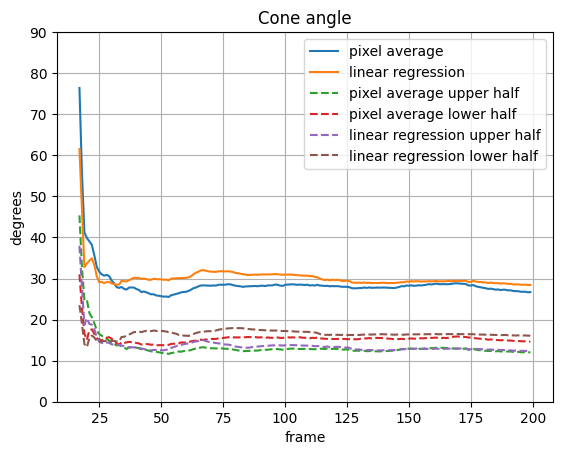

In [128]:

plt.plot(cone_angle_average, label="pixel average")
plt.plot(cone_angle_linear_regression, label="linear regression")

plt.plot(avg_up, label="pixel average upper half", linestyle="--")
plt.plot(-avg_low, label="pixel average lower half", linestyle="--")

plt.plot(lg_up, label="linear regression upper half", linestyle="--")
plt.plot(-lg_low, label="linear regression lower half", linestyle="--")


plt.legend()
plt.title("Cone angle")
plt.ylabel("degrees")
plt.xlabel("frame")
plt.ylim(0, 90)
plt.grid()

In [129]:
H00 = (H - nozzle_opening_detection_height) // 2
H01 = (H + nozzle_opening_detection_height) // 2

W00 = 0
W01 = int(nozzle_opening_detection_width)


In [130]:

# play_video_cv2(bw_video[:, H00:H01, W00:W01]*255.0)

In [133]:
from OSCC_postprocessing.analysis.hysteresis import * 
near_nozzle_signal = np.sum(bw_video[:, H00:H01, W00:W01], axis=(1,2))

(_,_, opening, closing), _, _ = detect_single_high_interval(near_nozzle_signal)

print("Nozzle opening: frame ", opening)
print("Nozzle closing: frame ", closing)

Nozzle opening: frame  17
Nozzle closing: frame  171


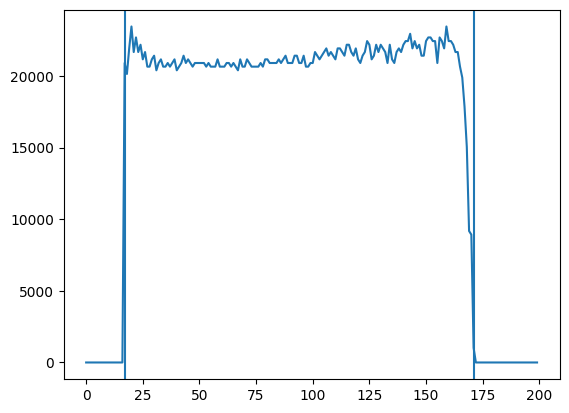

In [134]:
plt.plot(near_nozzle_signal)
plt.axvline(opening)
plt.axvline(closing)

In [135]:
def spary_features_from_bw_video(
        bw_video:np.ndarray,
        nozzle_opening_detection_height,
        nozzle_opening_detection_width, 
        umbrella_angle=180.0, 
        thres_penetration_num_pix=5):
    
    if umbrella_angle == 180.0:
        x_scale = 1.0
    else:
        tilt_angle = (180.0 - umbrella_angle) / 2.0
        tilt_angle_rad = tilt_angle / 180.0 * np.pi
        x_scale = 1.0 / np.cos(tilt_angle_rad)

    F, H, W = bw_video.shape
  
    bw_video_col_sum = np.sum(bw_video, axis=1) 
    area = bw_video_col_sum.sum(axis=-1)
    penetration_bw_x = penetration_bw_to_index(bw_video_col_sum > thres_penetration_num_pix)

    # bw boundary per frame
    boundary_split_points = bw_boundaries_all_points_single_plume(bw_video, parallel=True, umbrella_angle=180.0)

    # Volume Estimation
    
    upper_bw_width = bw_video[:, : H // 2, :].sum(axis=1)
    lower_bw_width = bw_video[:, H // 2 :, :].sum(axis=1)

    estimated_volume = x_scale * np.pi * 0.25 * np.sum((upper_bw_width + lower_bw_width) ** 2, axis=1)

    max_plume_radius = np.maximum(upper_bw_width, lower_bw_width)
    min_plume_radius = np.minimum(upper_bw_width, lower_bw_width)

    estimated_volume_max = np.pi * x_scale * np.sum(max_plume_radius**2, axis=1)
    estimated_volume_min = np.pi * x_scale * np.sum(min_plume_radius**2, axis=1)

    # Polar penetration 
    penetration_bw_polar = np.zeros(F)
    for i in range(F):
        pts = boundary_debug[i]

        if pts is None or len(pts) < 2:
            boundary_split_points[i] = None 
            continue

        if len(pts[0]) > 0 and len(pts[1]) > 0:
            uy, ux = pts[1][:, 0], pts[1][:, 1]
            ly, lx = pts[0][:, 0], pts[0][:, 1]

            max_r_upper = np.max(np.sqrt(uy**2 + ux**2))
            max_r_lower = np.max(np.sqrt(ly**2 + lx**2))
            penetration_bw_polar[i] = max(max_r_upper, max_r_lower)

    
    # boudary points 10-60% penetration 
    points_all_frames = bw_boundaries_xband_filter_single_plume(boundary_debug, _as_numpy(penetration_bw_x))

    lg_up = np.full(F, np.nan)
    lg_low = np.full(F, np.nan)
    avg_up = np.full(F, np.nan)
    avg_low = np.full(F, np.nan)

    for i in range(F):
        points = points_all_frames[i]
        if points is None:
            continue 
        
        elif (len(points[0]) > 0) and (len(points[1]) > 0) and (penetration_bw_polar[i] > 0):
            uy, ux = points[1][:, 0], points[1][:, 1]
            ly, lx = points[0][:, 0], points[0][:, 1]

            ang_up = np.atan(uy / ux) * 180.0 / np.pi
            ang_low = np.atan(ly / lx) * 180.0 / np.pi

            avg_up[i] = np.nanmean(ang_up)
            avg_low[i] = np.nanmean(ang_low)

            try:
                lg_up[i] = np.atan(linear_regression_fixed_intercept(ux, uy, 0.0)) * 180.0 / np.pi
                lg_low[i] = np.atan(linear_regression_fixed_intercept(lx, ly, 0.0)) * 180.0 / np.pi
            except ValueError:
                pass

    cone_angle_average = avg_up - avg_low
    cone_angle_linear_regression = lg_up - lg_low

    
    H00 = (H - nozzle_opening_detection_height) // 2
    H01 = (H + nozzle_opening_detection_height) // 2

    W00 = 0
    W01 = int(nozzle_opening_detection_width)

    near_nozzle_signal = np.sum(bw_video[:, H00:H01, W00:W01], axis=(1,2))

    (_,_, opening, closing), _, _ = detect_single_high_interval(near_nozzle_signal)

    return {
        "area": area,
        "penetration_bw_x": penetration_bw_x,
        "boundary": boundary,
        "estimated_volume": estimated_volume,
        "estimated_volume_max": estimated_volume_max,
        "estimated_volume_min": estimated_volume_min,
        "penetration_bw_polar": penetration_bw_polar,
        "cone_angle_average": cone_angle_average,
        "avg_up": avg_up,
        "avg_low": avg_low,
        "cone_angle_linear_regression": cone_angle_linear_regression,
        "lg_up": lg_up,
        "lg_low": lg_low,
        "nozzle_opening": opening,
        "nozzle_closing": closing
    }
  

In [137]:
spary_features_from_bw_video(
        bw_video,
        nozzle_opening_detection_height,
        nozzle_opening_detection_width
        )

{'area': array([       0,        0,        0,        0,        0,        0,
               0,        0,        0,        0,        0,        0,
               0,        0,        0,        0,        0,    31875,
           76500,   182070,   422025,   756840,  1086555,  1396890,
         1820955,  2134095,  2502315,  2870280,  3287460,  3651600,
         3968055,  4234275,  4545375,  4850100,  5147685,  5391465,
         5766315,  6101895,  6399990,  6647340,  6889335,  7159380,
         7418970,  7738485,  8027910,  8298720,  8603700,  8942340,
         9273585,  9604320,  9914400, 10235190, 10603410, 10961430,
        11328885, 11663955, 12028860, 12398355, 12742095, 13115925,
        13483380, 13857465, 14235375, 14615325, 14997315, 15378540,
        15787560, 16184085, 16534455, 16905480, 17264775, 17626365,
        17976990, 18351585, 18725415, 19004895, 19366995, 19696710,
        19984095, 20322990, 20618280, 20949525, 21299640, 21649500,
        22021800, 22396650, 22735545, 23